Analysis of the aggregated cell survival data
- With classic LQ fit
- With unweighted Rorvik

In [40]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf

Loading and importing data, option to correct doses here?

In [2]:
def Parse_data(input, exp):
    #Split colony counting data into cell survival for each sample
    #The survival is calculated for each triplicate separately and normalised to control
    #Also write LET to output for Rorvik calculations

    #inputs:
    #input = dataframe with the dose, plated cells and count of each triplicate for each sample, Format [Dose Plated Count1 Count2 Count3]

    #outputs:
    #output = dataframe with survival per triplicate and LET, Format [Dose LET Survival]

    def write_LET(rad_type):
        if rad_type == 'X':
            return 1
        if rad_type == 'Proton L':
            return 1.26
        if rad_type == 'Proton H':
            return 12.33

    triplicates = ['Count_1', 'Count_2', 'Count_3']

    #Isolate controls, calculate control survival for normalising
    control_data = input[input['Dose'] == 0]
    control_survival = control_data[triplicates].mean(axis=1)/control_data['Plated']

    #Write data to output with dose and survival
    output = pd.DataFrame(columns=['Dose', 'LET', 'Survival'])

    #Loop through rows of input to process data and write to output.
    #Each triplicate is processed separately
    for row in input.itertuples():
        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_1/row.Plated)/control_survival
        newrow['Survival'] = float(survival.iloc[0])
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_2/row.Plated)/control_survival
        newrow['Survival'] = float(survival.iloc[0])
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_3/row.Plated)/control_survival
        newrow['Survival'] = float(survival.iloc[0])
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        newrow['Experiment'] = exp
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

    return output



In [9]:
#Load and process data
#List all results folders
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results"
results_folders = []
for file in os.listdir(path):
    if os.path.isdir(os.path.join(path, file)) == True:
        results_folders.append(file)

#Loop through folders to extract all excels and write to dataframes: rorvik for aggregating all data for Rorvik fit, survival for mean survival per experiment LQ
X = pd.DataFrame(columns=['Dose', 'LET', 'Survival', 'Experiment'])
PL = pd.DataFrame(columns=['Dose', 'LET', 'Survival', 'Experiment'])
PH = pd.DataFrame(columns=['Dose', 'LET', 'Survival', 'Experiment'])

experiment = 0
for folder in results_folders:
    experiment += 1
    for file in os.listdir(os.path.join(path, folder)):
        if os.path.splitext(os.path.join(path, folder, file))[-1] == '.xlsx':
            #Read in if it's an excel file
            df = pd.read_excel(os.path.join(path, folder, file), index_col=None)

            #Check the radiation type and write to correct dataframe
            if df.tail(1)['Rad'].item() == 'X':
                data = Parse_data(df, experiment)
                #Correct X-ray dose
                data['Dose'] = 0.85*data['Dose']
                X = pd.concat([X, data])   
            if df.tail(1)['Rad'].item() == 'Proton L':
                PL = pd.concat([PL, Parse_data(df, experiment)])
            if df.tail(1)['Rad'].item() == 'Proton H':
                PH = pd.concat([PH, Parse_data(df, experiment)])



C:\Users\bhaan\AppData\Local\Temp\ipykernel_9644\2123109330.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_9644\848538426.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  PH = pd.concat([PH, Parse_data(df, experiment)])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_9644\2123109330.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is 

# Perform LQ fit on data

In [4]:
def Process_data(input):
    #Process [Dose Survival] data per sample into a mean and std per triplicate

    #inputs
    #df = dataframe [Dose Survival Experiment] per sample as outputted by the cell loading the data

    #output
    #df_means = dataframe ['Dose' 'Mean Survival' 'Experiment] per triplicate
    #df_stds = standard deviation of log of survival per triplicate

    #copy the input for processing
    df = input
    
    #Take log of survival, set zero survival to NaN
    df['Survival'] = np.log(np.array(df['Survival']))
    df['Survival'] = np.where(df['Survival'] == -np.inf, np.nan, df['Survival'])

    #Process into mean and std per triplicate
    df_means = pd.DataFrame(columns=['Dose', 'Mean Survival'])
    df_stds = np.zeros([1, int(len(df)/3)])

    for i in range(int(len(df)/3)):
        #Select triplicate
        trip = df[(i*3):((i+1)*3)]
        newrow = {}

        #Write dose
        newrow['Dose'] = trip['Dose'].iloc[0]
        newrow['Experiment'] = trip['Experiment'].iloc[0]

        #Calculate mean, ignoring any NaN values
        newrow['Mean Survival'] = np.nanmean(np.array(trip['Survival']))
        df_means = pd.concat([df_means, pd.DataFrame([newrow])])

        #Write standard dev
        df_stds[0][i] = np.nanstd(np.array(trip['Survival']))

    return df_means, df_stds 

In [49]:
def Perform_LQ_fit(sample):
    #Generate LQ fit

    #inputs:
    #sample = dataframe as ['Dose' 'Mean Survival'] for all triplicates, as outputted by 'Process_data'

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations
    
    dose = np.array(sample['Dose'], dtype='float')
    X = np.column_stack((dose, np.square(dose)))
    y = -(np.array(sample['Mean Survival'], dtype = 'float'))

    constraint = ['x1>=0', 'x2>=0']

    model = sm.OLS(y, X)
    results = model.fit()
    

    #In case it refuses to follow LQ formalism, force second parameter to zero
    if len(results.params)==1:
        results.params = [results.params, 0]
        results.params = np.array(results.params)
    elif results.params[1] < 0:
        model = sm.OLS(y, X[:,0])
        results = model.fit()
        results.params = [results.params[0], 0]
        results.params = np.array(results.params)

    print(results.summary())
    return results.params

In [6]:
def LQ_func(d, a, b):
        return -(a*d + b*(np.square(d)))

In [10]:
#Process data for all
X_means, X_stds = Process_data(X) 
PL_means, PL_stds = Process_data(PL)
PH_means, PH_stds = Process_data(PH)


C:\Users\bhaan\AppData\Local\Temp\ipykernel_9644\873261343.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_means = pd.concat([df_means, pd.DataFrame([newrow])])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_9644\873261343.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_means = pd.concat([df_means, pd.DataFrame([newrow])])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_9644\873261343.py:15: RuntimeWarning: divide by zero encountered in log
  df['Survival'] = np.log(np.array(df['Surviva

In [11]:
#LQ fit X-rays

params_x = Perform_LQ_fit(X_means)


                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.996
Model:                            OLS   Adj. R-squared (uncentered):              0.995
Method:                 Least Squares   F-statistic:                              808.3
Date:                Tue, 25 Nov 2025   Prob (F-statistic):                    5.06e-08
Time:                        11:57:11   Log-Likelihood:                          2.7360
No. Observations:                   8   AIC:                                     -1.472
Df Residuals:                       6   BIC:                                     -1.313
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\bhaan\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  res = hypotest_fun_out(*samples, **kwds)


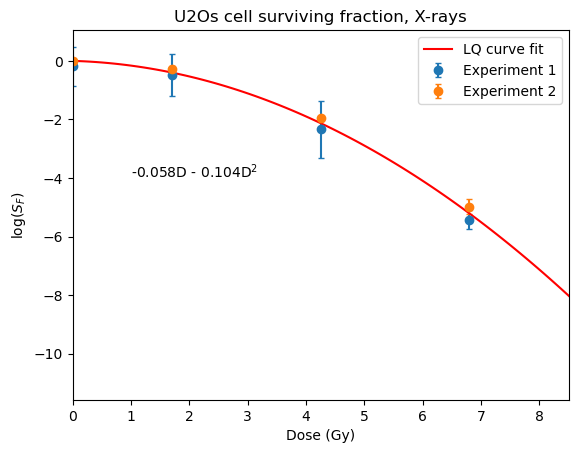

In [12]:
#Plot X-rays
#plot per experiment
for i in range(len(np.unique(np.array(X_means['Experiment'])))):
    exp = np.unique(np.array(X_means['Experiment']))[i]
    data = X_means[X_means['Experiment']==exp]
    error = X_stds[0][i*4:(i+1)*4]
    plt.errorbar(data['Dose'], data['Mean Survival'], error, fmt='o', capsize=2, label=f'Experiment {int(exp)}')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color='r', label='LQ curve fit')
plt.title('U2Os cell surviving fraction, X-rays')
plt.text(1, -4, f"-{round(params_x[0],3)}D - {round(params_x[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.legend()

In [14]:
#LQ fit proton low

params_pl = Perform_LQ_fit(PL_means)

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.994
Model:                            OLS   Adj. R-squared (uncentered):              0.992
Method:                 Least Squares   F-statistic:                              476.7
Date:                Tue, 25 Nov 2025   Prob (F-statistic):                    2.45e-07
Time:                        11:58:14   Log-Likelihood:                        0.017843
No. Observations:                   8   AIC:                                      3.964
Df Residuals:                       6   BIC:                                      4.123
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\bhaan\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  res = hypotest_fun_out(*samples, **kwds)


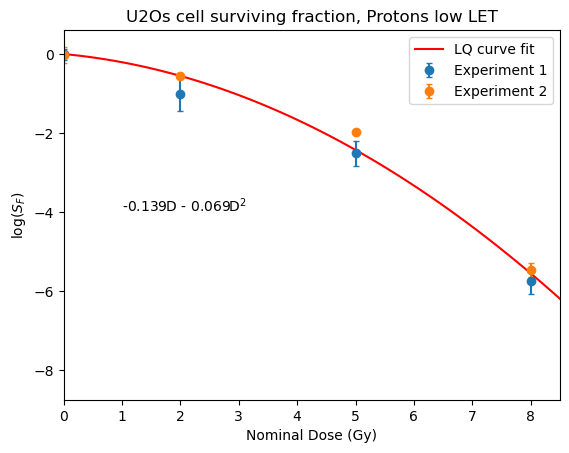

In [15]:
#Plot protons low
for i in range(len(np.unique(np.array(PL_means['Experiment'])))):
    exp = np.unique(np.array(PL_means['Experiment']))[i]
    data = PL_means[PL_means['Experiment']==exp]
    error = PL_stds[0][i*4:(i+1)*4]
    plt.errorbar(data['Dose'], data['Mean Survival'], error, fmt='o', capsize=2, label=f'Experiment {int(exp)}')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_pl[0], params_pl[1]), color='r', label='LQ curve fit')
plt.title('U2Os cell surviving fraction, Protons low LET')
plt.text(1, -4, f"-{round(params_pl[0],3)}D - {round(params_pl[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.legend()

In [50]:
#LQ fit proton high

params_ph = Perform_LQ_fit(PH_means)

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.951
Method:                 Least Squares   F-statistic:                              154.8
Date:                Tue, 25 Nov 2025   Prob (F-statistic):                    4.99e-06
Time:                        13:23:26   Log-Likelihood:                         -10.224
No. Observations:                   8   AIC:                                      22.45
Df Residuals:                       7   BIC:                                      22.53
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\bhaan\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=8
  res = hypotest_fun_out(*samples, **kwds)


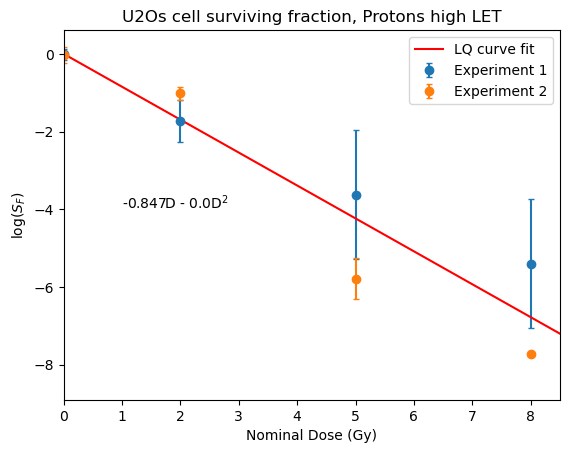

In [51]:
#Plot Protons High
for i in range(len(np.unique(np.array(PH_means['Experiment'])))):
    exp = np.unique(np.array(PH_means['Experiment']))[i]
    data = PH_means[PH_means['Experiment']==exp]
    error = PH_stds[0][i*4:(i+1)*4]
    plt.errorbar(data['Dose'], data['Mean Survival'], error, fmt='o', capsize=2, label=f'Experiment {int(exp)}')
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_ph[0], params_ph[1]), color='r', label='LQ curve fit')
plt.title('U2Os cell surviving fraction, Protons high LET')
plt.text(1, -4, f"-{round(params_ph[0],3)}D - {round(params_ph[1],3)}D$^2$")
plt.xlim([0, 8.5])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.legend()

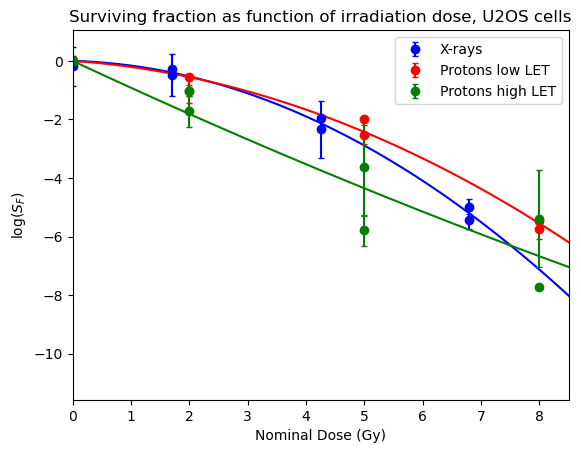

In [19]:
#Plot them all together
plt.errorbar(X_means['Dose'], X_means['Mean Survival'], X_stds, label='X-rays', color='b', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color='b')

plt.errorbar(PL_means['Dose'], PL_means['Mean Survival'], PL_stds, label='Protons low LET', color='r', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_pl[0], params_pl[1]), color='r')

plt.errorbar(PH_means['Dose'], PH_means['Mean Survival'], PH_stds, label='Protons high LET', color='g', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_ph[0], params_ph[1]), color='g')

plt.title('Surviving fraction as function of irradiation dose, U2OS cells')
plt.xlim([0, 8.5])
plt.xlabel('Nominal Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.legend()

# Rørvik fit

In [20]:
def Rorvik_fit(sample):
    #input
    #sample = pandas dataframe with dose, let, survival for given radiation type

    #output = fit data

    #Generate a design matrix of the format 'dose, LET*dose, dose^2, log survival
    dose = np.array(sample['Dose'], dtype='float')
    let = np.array(sample['LET'], dtype = 'float')
    X = np.column_stack((dose, dose*let, np.square(dose)))
    y = -(np.array(sample['Survival'], dtype = 'float'))

    model = sm.OLS(y, X)
    results = model.fit()
    print(results.summary())

    return results.params

In [21]:
#Remove any zero survivals
X_rorvik = X.dropna()
PL_rorvik = PL.dropna()
PH_rorvik = PH.dropna()

#Correct X_ray dose
#X_survival['Dose'] = 0.72*X_survival['Dose']

#Aggregate data back into one dataframe
total_data = pd.concat([X_rorvik, PL_rorvik, PH_rorvik])

#Fit curve
params = Rorvik_fit(total_data)

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.935
Model:                            OLS   Adj. R-squared (uncentered):              0.932
Method:                 Least Squares   F-statistic:                              326.9
Date:                Tue, 25 Nov 2025   Prob (F-statistic):                    2.57e-40
Time:                        11:59:13   Log-Likelihood:                         -91.510
No. Observations:                  71   AIC:                                      189.0
Df Residuals:                      68   BIC:                                      195.8
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

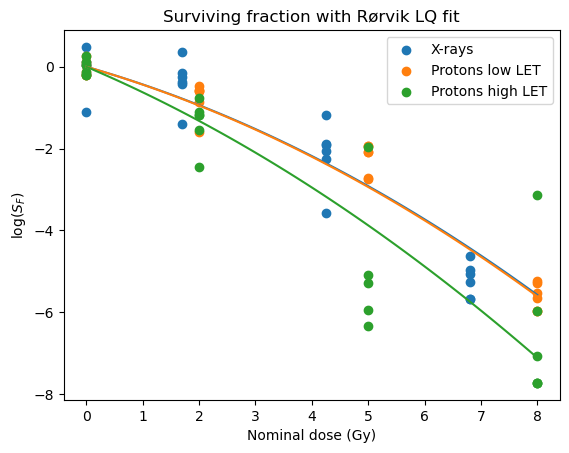

In [22]:
#Plot data
d = np.linspace(0,8,100)
let = X_rorvik.iloc[0]['LET']
y = -(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.scatter(X_rorvik['Dose'], X_rorvik['Survival'], label='X-rays')
plt.plot(d, y)

d = np.linspace(0,8,100)
let = PL_rorvik.iloc[0]['LET']
y = -(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.scatter(PL_rorvik['Dose'], PL_rorvik['Survival'], label='Protons low LET')
plt.plot(d, y)

d = np.linspace(0,8,100)
let = PH_rorvik.iloc[0]['LET']
y = -(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.scatter(PH_rorvik['Dose'], PH_rorvik['Survival'], label='Protons high LET')
plt.plot(d, y)

#Customise
plt.xlabel('Nominal dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction with Rørvik LQ fit')
plt.legend()

Attempt to implement RBE model according to Rorvik

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_9644\3824768219.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('LET (keV/$\mu$m)')


Text(0.5, 0.92, 'RBE as function of dose and LET, Rørvik')

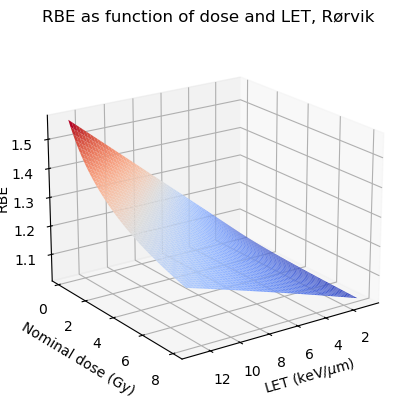

In [23]:
letvals = np.linspace(1, 13, 1000)
dosevals = np.linspace(0.1, 8, 1000)
letvals, dosevals = np.meshgrid(letvals, dosevals)

a_x = params[0]
b_x = params[2]
k = params[1]

RBEmin = 1
RBEmax = 1 + (k/a_x)*letvals
A_B = a_x/b_x

squareterm = np.square(A_B) + 4*dosevals*A_B*RBEmax + 4*np.square(dosevals)*np.square(RBEmin)
RBE = (1/(2*dosevals))*(np.sqrt(squareterm) - A_B)

fig = plt.figure()

ax1 = fig.add_subplot(1, 1, 1, projection='3d')
ax1.view_init(elev=20, azim=55, roll=0)
ax1.plot_surface(letvals, dosevals, RBE, cmap = 'coolwarm')
ax1.set_xlabel('LET (keV/$\mu$m)')
ax1.set_ylabel('Nominal dose (Gy)')
ax1.set_zlabel('RBE', rotation=90)
ax1.zaxis.labelpad=-0.8 
ax1.set_title('RBE as function of dose and LET, Rørvik')


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_9644\1626334991.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('LET (keV/$\mu$m)')


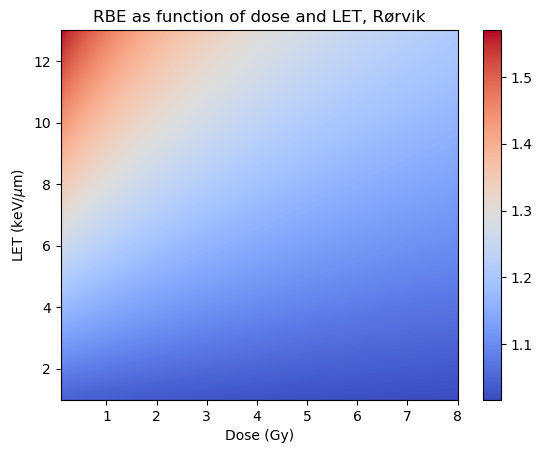

In [24]:
plt.pcolormesh(dosevals, letvals, RBE, cmap='coolwarm')
plt.ylabel('LET (keV/$\mu$m)')
plt.xlabel('Dose (Gy)')
plt.title('RBE as function of dose and LET, Rørvik')
plt.colorbar()